<a href="https://colab.research.google.com/github/EduardoAlvesP/ml-study/blob/main/regress%C3%A3o_linear_gradiente_descendente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

[ 4.36111422  1.96849873 -2.89631392  0.97505082  0.02185083  4.02162099
  7.05478758]
1983.3266900751698 1.2510129018917302


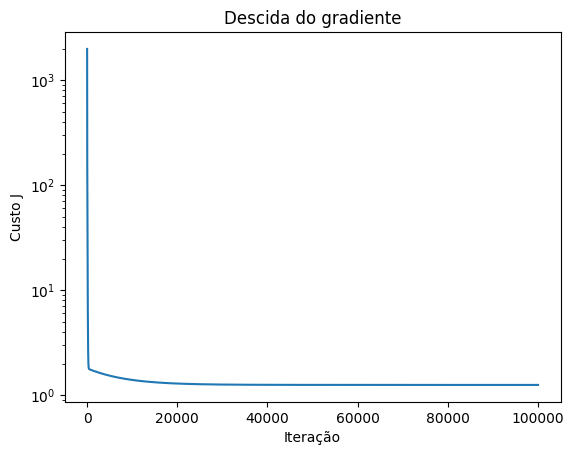

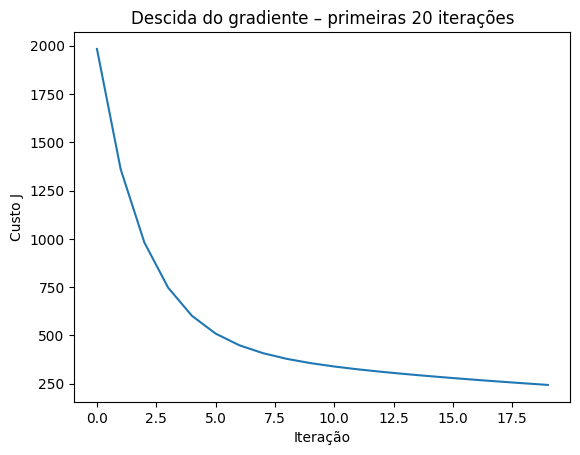

In [31]:

# fixa os tetas e soma somatorio dos (tetaj * xj + outros tetas* xs - y) * xj /m
def preve(tetas,dados):
  return dados @ tetas

def valor_real(dados):
  return dados.sum(axis=1) * 10


def erros_matriz(dados,tetas,y):
    return (np.sum((y - preve(tetas,dados))**2))/(2*len(dados))

def regressao_linear(tetas,dados,iteracoes,LR,y):
  historico_custo = []
  novos_tetas = tetas
  for i in range(0,iteracoes):
    calculo = dados @ novos_tetas
    calculo = calculo - y
    derivada = (calculo @ dados)/ len(dados)
    novos_tetas = novos_tetas - LR*derivada
    historico_custo.append(erros_matriz(dados,novos_tetas,y))
  return novos_tetas, historico_custo
LR = 0.001
np.random.seed(42)

aleatorios = np.random.randint(0, 13, size=(100, 6))   # 100 linhas × 6 colunas, valores de 0 a 12
uns = np.ones((100, 1))                               # coluna de 1s (o x0)
X = np.hstack([uns, aleatorios])                      # 100 × 7

tetas_verdadeiros = np.array([5, 2, -3, 1, 0, 4, 7])
ruido = np.random.randn(100) * 2
y = X @ tetas_verdadeiros + ruido

novos_tetas, historico_custo = regressao_linear(np.zeros(7),X,100000,LR,y)
print(novos_tetas)
print(historico_custo[0], historico_custo[-1])


plt.plot(historico_custo)
plt.xlabel("Iteração")
plt.ylabel("Custo J")
plt.title("Descida do gradiente")
plt.yscale("log")
plt.show()

plt.plot(historico_custo[:20])
plt.xlabel("Iteração")
plt.ylabel("Custo J")
plt.title("Descida do gradiente – primeiras 20 iterações")
plt.show()


## Gradiente descendente — o que eu aprendi

**Ideia geral:** o custo J é tipo um terreno, com os tetas no chão e o erro na altura. O gradiente é ir descendo esse terreno passo a passo até chegar no fundo do vale.

### Erro x custo
- **Erro** de uma linha: `chute − real`. Pode ser negativo (chutou baixo) ou positivo (chutou alto).
- **Custo de uma linha:** o erro ao quadrado.
- **Custo total (J):** a média dos erros ao quadrado de todas as linhas, dividida por 2: `J = (1/2m) · Σ (chute − real)²`.

### A derivada parcial
∂J/∂θj é quanto o custo muda se eu mexer **só** no θj, deixando todo o resto fixo (os outros tetas, os x e o y).

Pra regressão linear com erro ao quadrado, ela sempre dá:

`∂J/∂θj = (1/m) · Σ (chute − real) · xj`

De onde vem (regra da cadeia):
- a derivada do quadrado dá `2 · (chute − real)`, e esse 2 cancela com o 1/2 do J;
- a derivada do chute em relação ao θj dá `xj`, porque os outros termos são constantes e somem.

Por isso, na derivada, o erro entra **sem** elevar ao quadrado.

### Atualização
`teta novo = teta − lr · derivada`, com todos os tetas atualizados juntos no mesmo passo.

- Derivada positiva → o teta desce.
- Derivada negativa → o teta sobe.
- Derivada zero → chegou no fundo.
- O lr é só o multiplicador do passo. Se for grande demais, o custo explode; se for pequeno demais, fica lento.

### No código (numpy, sem for nas contas)
- `dados @ tetas` → o chute de todas as linhas.
- `chutes − y` → o erro de cada linha.
- `erros @ dados` → a soma de erro × xj pra cada teta de uma vez (vetor @ matriz percorre as colunas).
- Divide por m e tem a derivada de todos os tetas.

### Teste com dados aleatórios
Gerei 100 linhas com tetas verdadeiros `[5, 2, -3, 1, 0, 4, 7]` + ruído e rodei 100.000 iterações começando de tudo zero.

| | θ0 | θ1 | θ2 | θ3 | θ4 | θ5 | θ6 |
|---|---|---|---|---|---|---|---|
| Verdadeiros | 5 | 2 | −3 | 1 | 0 | 4 | 7 |
| Encontrados | 4,36 | 1,97 | −2,90 | 0,98 | 0,02 | 4,02 | 7,05 |

O custo caiu de 1983 pra 1,25. Não chega a 0 por causa do ruído, que nenhum teta consegue prever.

### O que o gráfico do custo mostrou
1. Queda vertical no começo: os tetas das colunas grandes se ajustam rápido.
2. Descida lenta até umas 30 mil iterações: é o θ0 andando devagar, porque a coluna dele é só de 1s, bem menor que as outras (que vão até 12). Como a derivada é erro × x, ele recebe empurrões menores. Isso é problema de escala.
3. Linha reta depois de umas 40 mil: convergiu, rodar mais não muda nada.

### Próximos passos
- Normalizar as features e ver quantas iterações leva pra convergir.
- Colocar um critério de parada em vez de um número fixo de iterações.
- Comparar com a solução analítica (`np.linalg.lstsq`).